-----------------------------
#### Get GPT embeddings 
- for food reviews data

https://www.kaggle.com/datasets/snap/amazon-fine-food-reviews
---------------------------

**Load the Dataset:**

- The dataset used in this example is fine-food reviews from Amazon.
- It contains a total of 568,454 food reviews that Amazon users left up to October 2012.
- We will use a subset of this dataset, consisting of the 1,000 most recent reviews for illustration purposes.
- The reviews are in English and tend to be positive or negative.
- Each review has a ProductId, UserId, Score, review title (Summary), and review body (Text).

**Combine Review Summary and Review Text:**

- We will combine the review summary and review text into a single combined text.
- The model will encode this combined text, and it will output a single vector embedding.

In [1]:
import pandas as pd
import numpy as np

In [2]:
location = r'D:\Makesh\Working\AI\RPS\Day07\Dataset\FoodReview\Reviews.csv'

In [3]:
df = pd.read_csv(location)

In [4]:
df.shape

(568454, 10)

In [5]:
df.dtypes

Id                         int64
ProductId                 object
UserId                    object
ProfileName               object
HelpfulnessNumerator       int64
HelpfulnessDenominator     int64
Score                      int64
Time                       int64
Summary                   object
Text                      object
dtype: object

- The dataset contains a total of 568,454 food reviews Amazon users left up to October 2012. 
- We will use a subset of 2,000 most recent reviews for illustration purposes. 
- The reviews are in English and tend to be positive or negative. 
- Each review has a ProductId, UserId, Score, review title (Summary) and review body (Text).

In [6]:
pd.options.display.max_colwidth = None

In [6]:
df[['Summary',	'Text', 'Score']].sample(3)

,Summary,Text,Score
418197,love this baby food,My son loved this baby food! Too bad he no lo...,5
422814,blue chips,The chips are okay Not near as flavorful as th...,1
450580,Smoked eel fillets,If stored in the refrigerator give the content...,4


In [8]:
df.Score.describe()

count    568454.000000
mean          4.183199
std           1.310436
min           1.000000
25%           4.000000
50%           5.000000
75%           5.000000
max           5.000000
Name: Score, dtype: float64

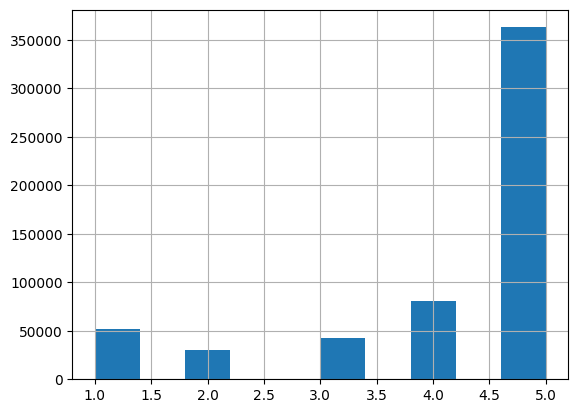

In [9]:
df.Score.hist();

We will combine the review `summary` and review `text` into a single combined text. The model will encode this combined text and it will output a single vector embedding.

In [7]:
df = df[["Time", "ProductId", "UserId", "Score", "Summary", "Text"]]
df = df.dropna()

df["combined"] = (
    "Title: " + df.Summary.str.strip() + "; Content: " + df.Text.str.strip() #It removes leading/trailing spaces so you don’t end up with:
)

In [8]:
df.shape

(568427, 7)

In [ ]:
# subsample to 2k most recent reviews and remove samples that are too long
top_n = 1000

# Sort the record in the ascending order of Time and take the last 2k records
df    = df.sort_values("Time").tail(top_n * 2)  
# Drop the Time
df.drop("Time", axis=1, inplace=True)

In [10]:
df.shape

(2000, 6)

In [11]:
df.sample(1)

,ProductId,UserId,Score,Summary,Text,combined
87517,B0050CPSBE,A4IL0CLL27Q33,1,Buyer beware,Nespresso makes GREAT coffee and GREAT machine...,Title: Buyer beware; Content: Nespresso makes ...


In [12]:
df["combined"] = (
    "Title: " + df.Summary.str.strip() + "; Content: " + df.Text.str.strip()
)
df.head(2)

,ProductId,UserId,Score,Summary,Text,combined
197286,B000PG8KGU,A30NLBXH8SIFSF,5,Party Pleasure!,Perfect for a cocktail party! You get your cho...,Title: Party Pleasure!; Content: Perfect for a...
200017,B009NEQAHQ,A1CN3VUX1DQ0FN,5,"Great taste, beautiful crystal!",My wife and I use this everyday in our dinners...,"Title: Great taste, beautiful crystal!; Conten..."


In [16]:
review = df.combined.sample(3).values

In [17]:
review

array(["Title: Good, but not Wolfgang Puck good; Content: Honestly, I have to admit that I expected a little better. That's not to say that this is bad coffee - in fact it's quite bold without being too acidic, and pretty satisfying overall. I think my main problem is that Wolfgang Puck's name is attached to it, so perhaps it set my expectations a little high. I have a Wolfgang Puck knife set that I adore, and is very high quality for what I paid for it. This coffee was on sale, so it was well worth it also, I just hoped for something that would knock my socks off - which it didn't. I also purchased the Breakfast blend, and Jamaica me crazy at the same time. The breakfast blend was the best, in my opinion, and the jamaican coffee smelled the best, but was the least successful.",
       'Title: Just a little is all it takes; Content: This hair balm is surprising lightweight.  I was expecting this to be a heavy, gooey, greasy experience, however I am pleasantly surprised and happy to rep

#### About tiktoken

- `tiktoken` is a fast open-source tokenizer by OpenAI. It is used to tokenize text into a sequence of integers that can be processed by OpenAI's GPT models. This is necessary because GPT models do not understand natural language, they only understand sequences of integers.

- Here are some of the benefits of using tiktoken:

    - It is `fast and efficient`. tiktoken is a highly optimized tokenizer that can tokenize text at a high rate. This is important for applications that require real-time processing of text.
    - It is `accurate`. tiktoken produces accurate tokenizations that capture the meaning of the original text. This is important for applications that require high-quality results, such as machine translation and natural language generation.
    - It is `easy to use`. tiktoken has a simple and easy-to-use API that makes it easy to integrate into existing applications.

In [18]:
#!pip install tiktoken

In [18]:
import tiktoken

**Tokenize a text string:**

- tiktoken.get_encoding 
    - function is used to load an encoding by name. 
    - The first time this function is called for a given encoding name, it will download the encoding from the internet. 
    - Later calls will use the cached version of the encoding.
    - The `tiktoken.get_encoding` function takes one argument, which is the encoding name. 
    - The encoding name is a string that identifies the encoding. 
        - For example, the encoding name "cl100k_base" identifies the BPE encoding that was trained on the cl100k dataset.
        
- The `tiktoken.get_encoding` function returns an Encoding object. 
    - The Encoding object has the following methods:

        - `encode`(text): Encodes a text string into a sequence of integers.
        - `decode`(tokens): Decodes a sequence of integers into a text string.
        - `vocab_size()`: Returns the size of the vocabulary.
        - `eos()`: Returns the ID of the end-of-sentence token.
        - `pad()`: Returns the ID of the pad token.

In [19]:
# To get the tokeniser corresponding to a specific model in the OpenAI API:
enc = tiktoken.encoding_for_model("gpt-4")
enc

<Encoding 'cl100k_base'>

In [20]:
enc = tiktoken.encoding_for_model("gpt-3.5-turbo")
enc

<Encoding 'cl100k_base'>

In [21]:
# # this the encoding for text-embedding-ada-002
encoding = tiktoken.get_encoding("cl100k_base")

tokens   = encoding.encode("This is a text string at doddaballapura road.")
print(tokens)

[2028, 374, 264, 1495, 925, 520, 294, 14898, 370, 543, 391, 5808, 5754, 13]


**Decode a sequence of tokens**

In [22]:
text = encoding.decode(tokens)
print(text)

This is a text string at doddaballapura road.


In [23]:
num_tokens = len(tokens)
print(num_tokens)

14


... back to code

In [24]:
import os
import openai
from openai import OpenAI

In [25]:
# embedding model parameters
embedding_model    = "text-embedding-3-small" # smallest
embedding_encoding = "cl100k_base"  # this the encoding for text-embedding-ada-002

max_tokens         = 8000  # the maximum for text-embedding-ada-002 is 8191

In [26]:
encoding = tiktoken.get_encoding(embedding_encoding)

In [27]:
# get the number of tokens for each sample ('combined')
df["n_tokens"] = df.combined.apply(lambda x: len(encoding.encode(x)))

In [28]:
df.sample(2)

,ProductId,UserId,Score,Summary,Text,combined,n_tokens
97814,B0040J7HIU,A2VB92E7TA6EUH,3,not 40 bars,There was NOT 40 bars in my box. I opened the box and the bars were all over the place like they were tossed in there and not lined up to keep count. I got 36 bars...I counted twice,Title: not 40 bars; Content: There was NOT 40 bars in my box. I opened the box and the bars were all over the place like they were tossed in there and not lined up to keep count. I got 36 bars...I counted twice,54
115908,B000LQJL6M,A1C94XH7D2TVQ9,5,croatia with go ahead tours-Tamara,Just got back from a wonderful tour with go ahead tours in croatia/slovenia. Our amazing tour director Tamara shared this wonderful decadent treat. I enjoy the richness with not being so sweet. Everyone in our group(40 americans) bought this treat at their local grocery stores.. I am ordering more because my luggage was so small. so glad to see that i can order more. Definitely a great representive of Croatia!!!,Title: croatia with go ahead tours-Tamara; Content: Just got back from a wonderful tour with go ahead tours in croatia/slovenia. Our amazing tour director Tamara shared this wonderful decadent treat. I enjoy the richness with not being so sweet. Everyone in our group(40 americans) bought this treat at their local grocery stores.. I am ordering more because my luggage was so small. so glad to see that i can order more. Definitely a great representive of Croatia!!!,108


<Axes: >

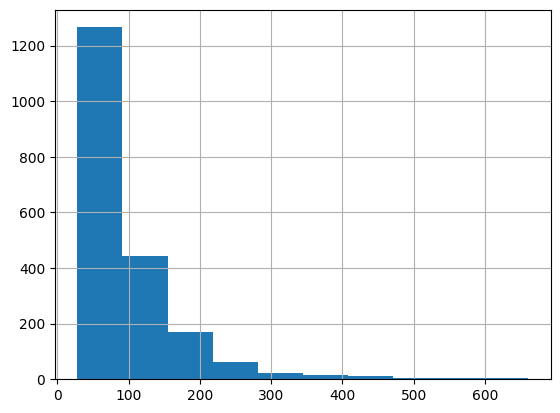

In [29]:
df.n_tokens.hist()

In [52]:
df.n_tokens.describe()

count    2000.000000
mean       95.473500
std        76.910467
min        28.000000
25%        46.000000
50%        71.000000
75%       114.000000
max       661.000000
Name: n_tokens, dtype: float64

In [30]:
# number of samples with number of tokens more than max_tokens
df[df.n_tokens > 250].sample(2)

,ProductId,UserId,Score,Summary,Text,combined,n_tokens
411373,B000LKVL16,A2YRK0YLBN5CC2,3,"Good flavor, but a wet mess","I got the teriyaki flavor and, while the flavor is good and the texture is also good once you get it into your mouth, it can be a mess getting it there. As other reviewers have noted, this is not like your typical dry jerky. It seems more like something that would be created by the company that makes SlimJims or something - it's moist and chewy. The individual packets don't tear easily, either, despite being notched at the end. You know how sometimes plastic can tear very cleanly, but sometimes it turns into a ragged edge and becomes a struggle? That's what happens with these 8 times out of 10. So if you're out and about (not near a sink) and you try to open it and the tear doesn't work perfectly, you potentially have liquid dripping out onto you, certainly on your fingers as you're trying to get the jerky out of the package and into your mouth. And the liquid dries sticky.<br /><br />Anyway, as I said, the flavor is good and I've now eaten most of mine, but I have taken to opening the package with scissors and eating them only at home so I can wash my hands afterward.","Title: Good flavor, but a wet mess; Content: I got the teriyaki flavor and, while the flavor is good and the texture is also good once you get it into your mouth, it can be a mess getting it there. As other reviewers have noted, this is not like your typical dry jerky. It seems more like something that would be created by the company that makes SlimJims or something - it's moist and chewy. The individual packets don't tear easily, either, despite being notched at the end. You know how sometimes plastic can tear very cleanly, but sometimes it turns into a ragged edge and becomes a struggle? That's what happens with these 8 times out of 10. So if you're out and about (not near a sink) and you try to open it and the tear doesn't work perfectly, you potentially have liquid dripping out onto you, certainly on your fingers as you're trying to get the jerky out of the package and into your mouth. And the liquid dries sticky.<br /><br />Anyway, as I said, the flavor is good and I've now eaten most of mine, but I have taken to opening the package with scissors and eating them only at home so I can wash my hands afterward.",267
354602,B000LKU3A6,A2YRK0YLBN5CC2,3,"Good flavor, but a wet mess","I got the teriyaki flavor and, while the flavor is good and the texture is also good once you get it into your mouth, it can be a mess getting it there. As other reviewers have noted, this is not like your typical dry jerky. It seems more like something that would be created by the company that makes SlimJims or something - it's moist and chewy. The individual packets don't tear easily, either, despite being notched at the end. You know how sometimes plastic can tear very cleanly, but sometimes it turns into a ragged edge and becomes a struggle? That's what happens with these 8 times out of 10. So if you're out and about (not near a sink) and you try to open it and the tear doesn't work perfectly, you potentially have liquid dripping out onto you, certainly on your fingers as you're trying to get the jerky out of the package and into your mouth. And the liquid dries sticky.<br /><br />Anyway, as I said, the flavor is good and I've now eaten most of mine, but I have taken to opening the package with scissors and eating them only at home so I can wash my hands afterward.","Title: Good flavor, but a wet mess; Content: I got the teriyaki flavor and, while the flavor is good and the texture is also good once you get it into your mouth, it can be a mess getting it there. As other reviewers have noted, this is not like your typical dry jerky. It seems more like something that would be created by the company that makes SlimJims or something - it's moist and chewy. The individual packets don't tear easily, either, despite being notched at the end. You know how sometimes p

In [31]:
# number of samples with number of tokens less than max_tokens
df[df.n_tokens <= max_tokens].shape

(2000, 7)

#### Get embeddings and save them for future reuse
- Ensure you have your API key set in your environment

In [32]:
from openai import OpenAI

client = openai.OpenAI()

In [33]:
def get_embedding(text, model="text-embedding-3-small"):
    text = text.replace("\n", " ")
    return client.embeddings.create(input = [text], model=model).data[0].embedding

In [34]:
df.shape

(2000, 7)

In [ ]:
%%time
# This may take a few minutes (10 - 20 mins)
# create embeddings for all samples line by line
# df['ada_embedding'] = df.combined.apply(lambda x: get_embedding(x, model='text-embedding-3-small'))

CPU times: total: 0 ns
Wall time: 7.63 μs


#### Options for faster obtaining of embeddings

**Option 1** - Batch Processing
- This reduces the overhead associated with making individual API calls and can significantly reduce the total time required.

In [36]:
def get_embeddings_batch(texts, model='text-embedding-3-small'):
    # Using the client to create embeddings
    response = client.embeddings.create(input=texts, model=model)
    
    # Extract embeddings from the response
    return [embedding.embedding for embedding in response.data]

In [37]:
batch_size = 50  # Adjust based on API limits and memory, 50, 100, 150 ...
embeddings = []

In [38]:
%%time
for i in range(0, len(df), batch_size):
    
    batch = df.combined[i:i+batch_size].tolist()
    
    embeddings.extend(get_embeddings_batch(batch))

df['ada_embedding'] = embeddings

CPU times: total: 609 ms
Wall time: 1min 2s


**Option 2** - Parallel Processing with Threading:
- Using multiple threads can help make API calls concurrently, thus utilizing available resources more efficiently.

In [39]:
from concurrent.futures import ThreadPoolExecutor

In [40]:
def get_embeddings_batch(texts, model='text-embedding-3-small'):
    # Using the client to create embeddings
    response = client.embeddings.create(input=texts, model=model)
    
    # Extract embeddings from the response
    return [embedding.embedding for embedding in response.data]

In [41]:
def process_batch(batch):
    return get_embeddings_batch(batch)

In [42]:
batch_size = 50  # Adjust based on API limits and memory
embeddings = []

In [43]:
# Number of threads to use. Adjust based on your system's capabilities
max_workers = 10

In [44]:
%%time
with ThreadPoolExecutor(max_workers=max_workers) as executor:
    
    # Split the data into batches and process them in parallel
    batches = [df.combined[i:i+batch_size].tolist() for i in range(0, len(df), batch_size)]
    results = executor.map(process_batch, batches)
    
    # Flatten the list of lists into a single list of embeddings
    embeddings = [embedding for batch_result in results for embedding in batch_result]

CPU times: total: 547 ms
Wall time: 9.87 s


In [45]:
# Add the embeddings to the DataFrame
df['ada_embedding'] = embeddings

In [46]:
df.sample(1)

,ProductId,UserId,Score,Summary,Text,combined,n_tokens,ada_embedding
119052,B004IREFUM,A60R8D38PUSPZ,5,Great coffee,"Very delicious coffee, just when you need a good cup of coffee in a rush, there you have this little packs full of flavor and aroma. Loved it!","Title: Great coffee; Content: Very delicious coffee, just when you need a good cup of coffee in a rush, there you have this little packs full of flavor and aroma. Loved it!",39,"[-0.015959972515702248, -0.028799762949347496, -0.06062065064907074, -0.04390539973974228, 0.007565199863165617, -0.09816187620162964, 0.002999459393322468, 0.07250705361366272, 0.01432559173554182, -0.023166103288531303, 0.03357908874750137, -0.025085261091589928, 0.0014014501357451081, 0.01924111321568489, 0.00847525242716074, 0.04536643624305725, -0.02224985882639885, -0.01350840087980032, 0.023636605590581894, 0.03573349863290787, -0.004376919940114021, 0.01753244362771511, -0.008178092539310455, 0.06596953421831131, 0.01241881400346756, 0.02954266220331192, -0.041701462119817734, -0.0005273817223496735, 0.04937809705734253, -0.055172719061374664, -0.001953208353370428, -0.021940317004919052, 0.033331453800201416, -0.009831045754253864, 0.01577424630522728, -0.017619114369153976, -0.008227619342505932, 0.004181908909231424, 0.037640273571014404, -0.035683970898389816, 0.006224884185940027, 0.010289167053997517, 0.02154410444200039, -0.001192509545944631, 0.0010841699549928308, -0.017272427678108215, 0.009942480362951756, -0.03043414279818535, -0.004250008147209883, 0.029815059155225754, -0.01964970864355564, 0.01977352611720562, 0.014796094968914986, -0.0034792490769177675, -0.00041130356839857996, -0.04085950925946236, 0.00856192409992218, 0.02825496904551983, 0.036624979227781296, -0.017928656190633774, -0.02224985882639885, -0.025345277041196823, 0.05353833734989166, 0.02959218993782997, 0.017210520803928375, -0.08067895472049713, 0.018386779353022575, -0.06448373198509216, 0.01088967826217413, 0.009676274843513966, -0.0034792490769177675, 0.011781157925724983, -0.000689891108777374, -0.055172719061374664, -0.04130524769425392, 0.0030412476044148207, -0.07022882997989655, 0.012555012479424477, -0.03464391082525253, -0.05502413958311081, -0.039051786065101624, 0.016405710950493813, -0.016331421211361885, -0.02372327819466591, -0.022274622693657875, -0.062354087829589844, -0.03920036554336548, 0.03684784844517708, -0.01652952842414379, -0.024045201018452644, 0.02800733596086502, 0.011725440621376038, 0.042469125241041183, 0.0008612998644821346, -0.03209328651428223, 0.0336533784866333, -0.0005552404909394681, 0.07438907027244568, 0.005110533908009529, 0.07102125138044357, ...]"


In [47]:
save_file_path = r'D:\Makesh\Working\AI\RPS\Day07\Dataset\FoodReview\amazon_food_reviews_with_embeddings_2k.csv'
df.to_csv(save_file_path)

To load the data from a saved file, you can run the following:

In [48]:
df_loaded = pd.read_csv(save_file_path)
df_loaded['ada_embedding'] = df_loaded.ada_embedding.apply(eval).apply(np.array)

In [50]:
df_loaded.sample

<bound method NDFrame.sample of       Unnamed: 0   ProductId          UserId  Score  \
0         197286  B000PG8KGU  A30NLBXH8SIFSF      5   
1         200017  B009NEQAHQ  A1CN3VUX1DQ0FN      5   
2         200016  B009NEQAHQ   AM2KJSYDRR0KI      4   
3         112175  B0045H0KYA  A3RCEQLJPQXSB8      5   
4         197216  B007FK3HHG  A3VJ27010XUWTF      5   
...          ...         ...             ...    ...   
1995      325174  B0002DGRRA  A3SSEJ8IEM4YGW      5   
1996      325175  B0002DGRRA   AUINI96NMGXUI      5   
1997      198642  B002AQL00G   AEWJD0G85FPSG      5   
1998       14783  B000S859NC  A2H7STZ2URUCOE      5   
1999      302675  B000UBH9YE  A1CM50V04TUUPF      5   

                                                  Summary  \
0                                         Party Pleasure!   
1                         Great taste, beautiful crystal!   
2                                                  Yummy!   
3                                                    Good   
4 